In [1]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from merf import MERF

from utils import plot_lorenz_curve


2026-05-25 14:13:04.591 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-25 14:13:04.593 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-25 14:13:04.594 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-25 14:13:04.595 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-25 14:13:04.595 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-25 14:13:04.596 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


In [2]:
df = pl.read_csv("data/final.csv")

In [3]:
df.columns

['gemeente',
 'year',
 'month',
 'hour',
 'flow_in',
 'flow_out',
 'total_hourly_flow',
 'avg_temp',
 'avg_precip',
 'avg_mun_wind',
 'bad_weather_ratio',
 'inbound_push_ratio',
 'total_accidents',
 'total_cycling_accidents',
 'severity',
 'light',
 'intersection',
 'school_peak',
 'car_conflict',
 'slick',
 'local_accidents',
 'avg_income_per_capita',
 'prof_earner_ratio',
 'avg_employment_rate',
 'relative_sensor_age',
 'total_pop',
 'pct_young_children',
 'pct_school_kids',
 'pct_uni_students',
 'pct_young_profs',
 'pct_senior_profs',
 'pct_seniors',
 'pct_male',
 'pct_female',
 'pct_belgian',
 'pct_foreign',
 'pct_single',
 'pct_married',
 'pct_widowed',
 'pct_divorced']

In [4]:
df.head()

gemeente,year,month,hour,flow_in,flow_out,total_hourly_flow,avg_temp,avg_precip,avg_mun_wind,bad_weather_ratio,inbound_push_ratio,total_accidents,total_cycling_accidents,severity,light,intersection,school_peak,car_conflict,slick,local_accidents,avg_income_per_capita,prof_earner_ratio,avg_employment_rate,relative_sensor_age,total_pop,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced
str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Peer""",2024,2,20,49.0,13.0,62.0,8.1,0.189655,14.668966,0.2413793,0.790323,0,0,0,0,0,0,0,0,0,24131.47889,0.582397,0.730329,2,16585,0.072897,0.110944,0.078806,0.161532,0.355261,0.220561,0.502502,0.497498,0.922159,0.077841,0.444317,0.424661,0.049985,0.081037
"""Kampenhout""",2024,10,21,51.0,242.0,293.0,12.345161,0.109677,7.896774,0.096774,0.174061,0,0,0,0,0,0,0,0,0,29878.449091,0.577221,0.706726,2,12528,0.078624,0.121089,0.089879,0.164272,0.349697,0.19644,0.493135,0.506865,0.940374,0.059626,0.484674,0.382902,0.046296,0.086127
"""Zemst""",2023,3,17,1282.0,1956.0,3238.0,9.612903,0.180645,19.277419,0.225806,0.395923,0,0,0,0,0,0,0,0,0,30505.789974,0.561942,0.695788,1,23357,0.08156,0.122918,0.083144,0.149848,0.355611,0.206919,0.488719,0.511281,0.962966,0.037034,0.465214,0.404418,0.052832,0.077536
"""Halle""",2025,4,0,9.0,0.0,9.0,10.186667,0.016667,6.973333,0.033333,1.0,0,0,0,0,0,0,0,0,0,26196.065103,0.594342,0.724252,3,42884,0.089404,0.120115,0.092715,0.185617,0.316435,0.195714,0.487385,0.512615,0.894273,0.105727,0.519308,0.341456,0.055685,0.083551
"""Aalst""",2022,8,15,2359.0,2077.0,4436.0,25.893548,0.016129,13.390323,0.032258,0.531785,1,0,0,0,0,0,0,0,0,22937.319664,0.590854,0.759204,3,88854,0.083744,0.115425,0.08721,0.176447,0.335145,0.202028,0.490434,0.509566,0.902762,0.097238,0.481408,0.358048,0.05823,0.102314


In [5]:
# creating a new feature `is_school_peak`. if the hour is in the 7 to 9 or 15 to 17 intervals
# it's set to 1, otherwise zero.
df = df.with_columns(
    pl.when((pl.col("hour").is_between(7, 9)) | (pl.col("hour").is_between(15, 17)))
    .then(1)
    .otherwise(0)
    .alias("is_school_peak")
)

In [6]:
sum_cols = [
    "total_accidents",
    "total_cycling_accidents",
    "car_conflict",
    "severity",
    "slick",
    "light",
    "intersection",
    "school_peak",
    "local_accidents",
]

mean_cols = [
    "total_hourly_flow",
    "avg_temp",
    "avg_precip",
    "avg_mun_wind",
    "bad_weather_ratio",
    "relative_sensor_age",
    "avg_income_per_capita",
    "prof_earner_ratio",
    "avg_employment_rate",
    "inbound_push_ratio",
]


demo_cols = [col for col in df.columns if col.startswith("pct_") or col == "total_pop"]

since the `final.csv` file is based on hourly basis, and we want to predict the number of accidents per year, I needed to aggregate the data to yearly-basis. accidents columns, which had count data were summed and other continuous features were averaged

In [7]:
# doing the aggregation for each municipality. different column types are treated differently. (see the note above)
df_yearly = df.group_by(["gemeente", "year"]).agg(
    [pl.col(c).sum() for c in sum_cols]
    + [pl.col(c).mean() for c in mean_cols]
    + [pl.col(c).mean() for c in demo_cols]
)

In [8]:
# these are some normalized features I calculated, based on athulya's initial eda
# accident_rate_per flow comes from dividing total_accidents by total_hourly flow
# and then there is accident_rate_per_capita and the severity_index, which is the total count of sever accidents divided by total_accidents
df_yearly = df_yearly.with_columns(
    [
        (pl.col("total_accidents") / pl.col("total_hourly_flow")).alias(
            "accident_rate_per_flow"
        ),
        (pl.col("total_accidents") / pl.col("total_pop")).alias(
            "accident_rate_per_capita"
        ),
        (pl.col("severity") / pl.col("total_accidents")).alias("severity_index"),
    ]
)

In [9]:
df_yearly.head()

gemeente,year,total_accidents,total_cycling_accidents,car_conflict,severity,slick,light,intersection,school_peak,local_accidents,total_hourly_flow,avg_temp,avg_precip,avg_mun_wind,bad_weather_ratio,relative_sensor_age,avg_income_per_capita,prof_earner_ratio,avg_employment_rate,inbound_push_ratio,total_pop,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced,accident_rate_per_flow,accident_rate_per_capita,severity_index
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Hamme""",2024,71,37,34,5,11,4,17,9,1,546.729167,12.002278,0.100273,12.8688,0.136627,2.0,24720.209027,0.605842,0.751132,0.565383,25554.0,0.078031,0.116968,0.089262,0.175511,0.335407,0.204821,0.492056,0.507944,0.929248,0.070752,0.467363,0.377906,0.05956,0.095171,0.129863,0.002778,0.070423
"""Ieper""",2025,0,0,0,0,0,0,0,0,0,806.315972,11.259447,0.0656,13.514413,0.120723,3.0,24945.082649,0.61574,0.757827,0.546953,35587.0,0.075814,0.106471,0.085368,0.165145,0.31978,0.247422,0.494647,0.505353,0.933178,0.066822,0.450389,0.392475,0.064181,0.092955,0.0,0.0,NaN
"""Beveren""",2024,181,58,32,8,14,9,17,19,1,0.0,11.584926,0.099307,13.406663,0.149333,2.0,27970.764195,0.590481,0.751132,0.5,50838.0,0.076085,0.113144,0.086766,0.165703,0.331956,0.226346,0.495909,0.504091,0.91528,0.08472,0.462567,0.393072,0.056985,0.087376,inf,0.00356,0.044199
"""Ardooie""",2023,50,10,8,1,3,0,5,5,0,282.746528,10.926925,0.116542,14.797531,0.196563,1.0,24571.395166,0.596579,0.76035,0.966817,9338.0,0.079674,0.109981,0.077211,0.174663,0.320947,0.237524,0.498822,0.501178,0.950096,0.049904,0.437567,0.416899,0.070358,0.075177,0.176837,0.005354,0.02
"""Meise""",2022,61,14,8,3,1,3,5,6,0,344.652778,12.0514,0.047198,12.753257,0.113532,1.0,27475.114411,0.562034,0.695224,0.527105,19991.0,0.087389,0.113451,0.090391,0.158621,0.337802,0.212346,0.487619,0.512381,0.912311,0.087689,0.464659,0.394628,0.056976,0.083738,0.17699,0.003051,0.04918


In [10]:
# previous year features
# so for each year, and each municipality, I created a new feature which indicated the last year's count of the said feature. if there is no previous year data available
# it's filled with 0
df_features = df_yearly.sort(["gemeente", "year"]).with_columns(
    [
        pl.col("severity")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_severe_count"),
        pl.col("light")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_dark_count"),
        pl.col("local_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_local_accidents"),
        pl.col("school_peak")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_school_accidents"),
        pl.col("slick")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_slick_accidents"),
        pl.col("car_conflict")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_carconflict_accidents"),
        pl.col("intersection")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_int_accidents"),
        pl.col("total_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_total_accidents"),
        pl.col("total_cycling_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_total_cyc_accidents"),
        pl.col("total_cycling_accidents")
        .mean()
        .over("gemeente")
        .alias("historical_town_avg"),
    ]
)

In [11]:
# creating some new features
df_features = df_features.with_columns(
    [
        (
            pl.col("pct_school_kids")
            * pl.col("total_pop")
            / pl.col("total_hourly_flow")
        ).alias("school_zone_exposure"),
        (pl.col("prev_year_total_accidents") / (pl.col("total_pop") / 1000)).alias(
            "risk_per_1k_residents"
        ),
        (pl.col("avg_mun_wind") * pl.col("avg_precip")).alias("weather_severity_index"),
        (pl.col("total_hourly_flow") / pl.col("total_pop")).alias("flow_density"),
    ]
)

In [12]:
# if a column has total_cycling_accidents as null, it looks at the previous years data, instead of the row after it,
# which is equivalent to looking into future. renames the feature to smoothed_target
df_features = df_features.sort(["gemeente", "year"]).with_columns(
    pl.col("total_cycling_accidents")
    .backward_fill()
    .over("gemeente")
    .alias("smoothed_target")
)

In [13]:
# clipping the total_hourly_flow so that they don't explode
upper_limit = df_features["total_hourly_flow"].quantile(0.99)
df_features = df_features.with_columns(
    pl.col("total_hourly_flow").clip(upper_bound=upper_limit)
)

In [14]:
features = [
    "total_hourly_flow",
    "avg_temp",
    "avg_precip",
    "avg_mun_wind",
    "avg_income_per_capita",
    "prof_earner_ratio",
    "avg_employment_rate",
    "total_pop",
    "pct_young_children",
    "pct_school_kids",
    "pct_uni_students",
    "pct_young_profs",
    "pct_senior_profs",
    "pct_seniors",
    "pct_male",
    "pct_belgian",
    "pct_single",
    "pct_married",
    "pct_widowed",
    "prev_year_severe_count",
    "prev_year_dark_count",
    "prev_year_total_accidents",
    "prev_year_school_accidents",
    "prev_year_slick_accidents",
    "prev_year_local_accidents",
    "prev_year_total_cyc_accidents",
    "historical_town_avg",
    "prev_year_carconflict_accidents",
    "prev_year_int_accidents",
    "school_zone_exposure",
    "risk_per_1k_residents",
    "flow_density",
    "bad_weather_ratio",
    "relative_sensor_age",
    "inbound_push_ratio",
]

In [15]:
df_features.null_count().pipe(sum).item() > 0  # type: ignore

False

In [16]:
# since we did some normalizations, there could be some division be zeros
# and therefore some infinity values. replacing those with zeros
# also converting them to float32 type
df_features = df_features.with_columns(
    [
        pl.when(pl.col(col).is_infinite()).then(0.0).otherwise(pl.col(col)).alias(col)
        for col in features
    ]
).with_columns([pl.col(col).cast(pl.Float32) for col in features])

In [17]:
df_features.head()

gemeente,year,total_accidents,total_cycling_accidents,car_conflict,severity,slick,light,intersection,school_peak,local_accidents,total_hourly_flow,avg_temp,avg_precip,avg_mun_wind,bad_weather_ratio,relative_sensor_age,avg_income_per_capita,prof_earner_ratio,avg_employment_rate,inbound_push_ratio,total_pop,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced,accident_rate_per_flow,accident_rate_per_capita,severity_index,prev_year_severe_count,prev_year_dark_count,prev_year_local_accidents,prev_year_school_accidents,prev_year_slick_accidents,prev_year_carconflict_accidents,prev_year_int_accidents,prev_year_total_accidents,prev_year_total_cyc_accidents,historical_town_avg,school_zone_exposure,risk_per_1k_residents,weather_severity_index,flow_density,smoothed_target
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f32,f64,f32,f32,f32,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f32,i64
"""Aalst""",2021,234,68,52,8,14,10,29,20,0,1318.430542,10.692369,0.096772,12.348918,0.145534,2.0,21372.589844,0.576508,0.744387,0.505033,87978.0,0.084942,0.11246,0.087204,0.177567,0.337994,0.199834,0.491475,0.508525,0.905806,0.094194,0.475005,0.362238,0.059981,0.102776,0.177484,0.00266,0.034188,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.400002,7.504377,0.0,1.195035,0.014986,68
"""Aalst""",2022,326,109,82,15,15,11,50,39,0,1627.590332,11.986206,0.071809,12.145395,0.119915,3.0,22937.320312,0.590854,0.759204,0.515943,88854.0,0.083744,0.115425,0.08721,0.176447,0.335145,0.202028,0.490434,0.509566,0.902762,0.097238,0.481408,0.358048,0.05823,0.102314,0.200296,0.003669,0.046012,8.0,10.0,0.0,20.0,14.0,52.0,29.0,234.0,68.0,77.400002,6.30134,2.633534,0.872147,0.018318,109
"""Aalst""",2023,254,105,79,9,25,17,49,37,0,1618.892334,12.159162,0.110651,14.147687,0.152623,4.0,24427.638672,0.591747,0.757155,0.519057,90068.0,0.082615,0.117689,0.086901,0.176544,0.333015,0.203235,0.490074,0.509926,0.895768,0.104232,0.48792,0.354577,0.056779,0.100724,0.156897,0.00282,0.035433,15.0,11.0,0.0,39.0,15.0,82.0,50.0,326.0,109.0,77.400002,6.547687,3.619488,1.565457,0.017974,105
"""Aalst""",2024,303,105,70,7,31,26,33,38,1,1758.822876,12.002277,0.100273,12.868799,0.136627,5.0,25065.582031,0.595392,0.751132,0.50729,90995.0,0.082477,0.119204,0.086873,0.176944,0.330359,0.204143,0.490917,0.509083,0.89273,0.10727,0.492214,0.351426,0.056256,0.100104,0.172274,0.00333,0.023102,9.0,17.0,0.0,37.0,25.0,79.0,49.0,254.0,105.0,77.400002,6.167193,2.791362,1.290387,0.019329,105
"""Aalst""",2025,0,0,0,0,0,0,0,0,0,2178.3125,12.230687,0.050635,11.941783,0.0869,6.0,26098.96875,0.599866,0.742867,0.509212,92131.0,0.081797,0.120122,0.088092,0.177606,0.326948,0.205436,0.491203,0.508797,0.88931,0.11069,0.497563,0.348124,0.055421,0.098892,0.0,0.0,NaN,7.0,26.0,1.0,38.0,31.0,70.0,33.0,303.0,105.0,77.400002,5.080538,3.288795,0.604669,0.023644,0


In [18]:
train_df = df_features.filter(pl.col("year").is_in([2021, 2022, 2023]))
val_df = df_features.filter(pl.col("year") == 2024)
test_df = df_features.filter(pl.col("year") == 2025)

In [19]:
X_train = train_df.select(features).to_pandas()
y_train = train_df.select("smoothed_target").to_pandas().values.flatten()

In [20]:
X_val = val_df.select(features).to_pandas()
y_val = val_df.select("smoothed_target").to_pandas().values.flatten()

In [21]:
X_test = test_df.select(features).to_pandas()

In [22]:
pop_weights = (train_df["total_pop"] / train_df["total_pop"].mean()).to_numpy()

In [23]:
print(
    f"Train: {X_train.shape}  ({train_df['gemeente'].n_unique()} municipalities, 2021 - 2023)\n"
)
print(f"Val: {X_val.shape}   ({val_df['gemeente'].n_unique()} municipalities, 2024)\n")
print(
    f"Test: {X_test.shape}  ({test_df['gemeente'].n_unique()} municipalities, 2025)\n"
)
print(f"Number of Features: {len(features)}")

Train: (148, 35)  (68 municipalities, 2021 - 2023)

Val: (68, 35)   (68 municipalities, 2024)

Test: (68, 35)  (68 municipalities, 2025)

Number of Features: 35


# Model 1
## Two Stage Model

for this model, I'm dividing them into two distinct categories. low risk ones, and high risk ones. threshold is set at the median

In [24]:
median_threshold = np.median(y_train)
print(f"Median threshold for low/high split: {median_threshold:.2f}")

Median threshold for low/high split: 23.50


In [25]:
y_train_tier = (y_train > median_threshold).astype(int)  # 0 = low, 1 = high
y_val_tier = (y_val > median_threshold).astype(int)

In [26]:
print(
    f"Train — Low risk: {(y_train_tier==0).sum()}, High risk: {(y_train_tier==1).sum()}"
)
print(
    f"Val   — Low risk: {(y_val_tier==0).sum()},   High risk: {(y_val_tier==1).sum()}"
)

Train — Low risk: 74, High risk: 74
Val   — Low risk: 33,   High risk: 35


In [27]:
scaler_two_stage = StandardScaler()
X_train_1 = scaler_two_stage.fit_transform(X_train)
X_val_1 = scaler_two_stage.transform(X_val)
X_test_1 = scaler_two_stage.transform(X_test)

In [28]:
stage1_model = LogisticRegression(max_iter=1000, C=0.5, random_state=7)
stage1_model.fit(X_train_1, y_train_tier, sample_weight=pop_weights)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",7
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

with `stage1_model` I'm trying to define whether it's gonna be low or high risk

In [29]:
p_high_val = stage1_model.predict_proba(X_val_1)[:, 1]
p_high_test = stage1_model.predict_proba(X_test_1)[:, 1]

In [30]:
low_mask = y_train_tier == 0
high_mask = y_train_tier == 1

In [31]:
model_low = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42,
)

In [32]:
model_low.fit(
    X_train[low_mask],
    y_train[low_mask],
    sample_weight=pop_weights[low_mask],
    verbose=False,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [33]:
model_high = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    random_state=42,
)

In [34]:
model_high.fit(
    X_train[high_mask],
    y_train[high_mask],
    sample_weight=pop_weights[high_mask],
    verbose=False,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [35]:
val_preds_1 = p_high_val * model_high.predict(X_val) + (
    1 - p_high_val
) * model_low.predict(X_val)

In [36]:
test_preds_1 = p_high_test * model_high.predict(X_test) + (
    1 - p_high_test
) * model_low.predict(X_test)

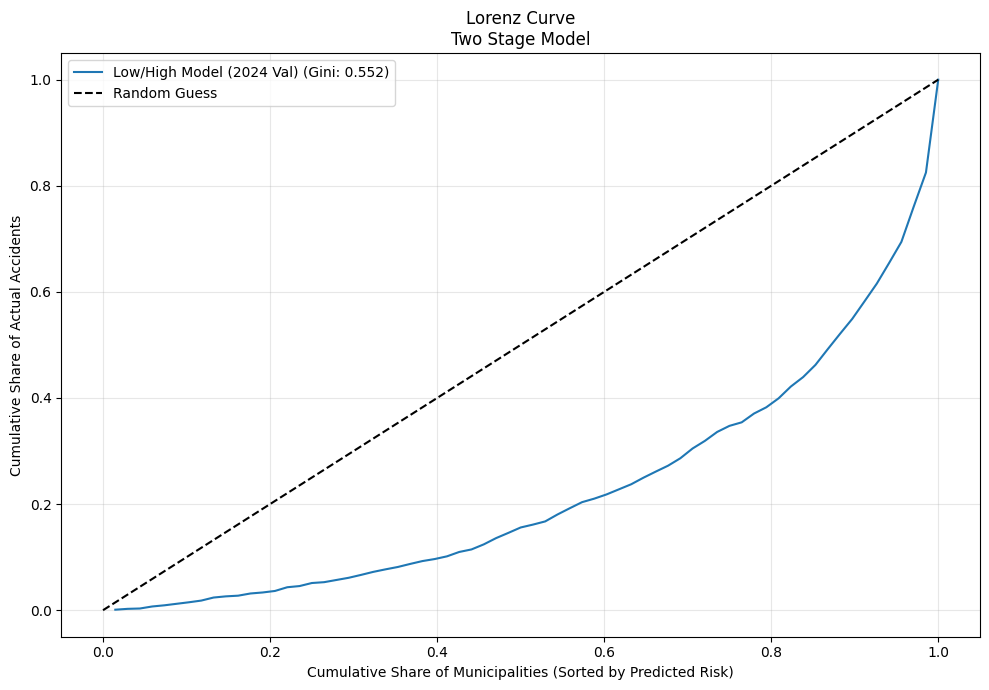

In [37]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_lorenz_curve(y_val, val_preds_1, "Low/High Model (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")
ax.set_title("Lorenz Curve\nTwo Stage Model")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

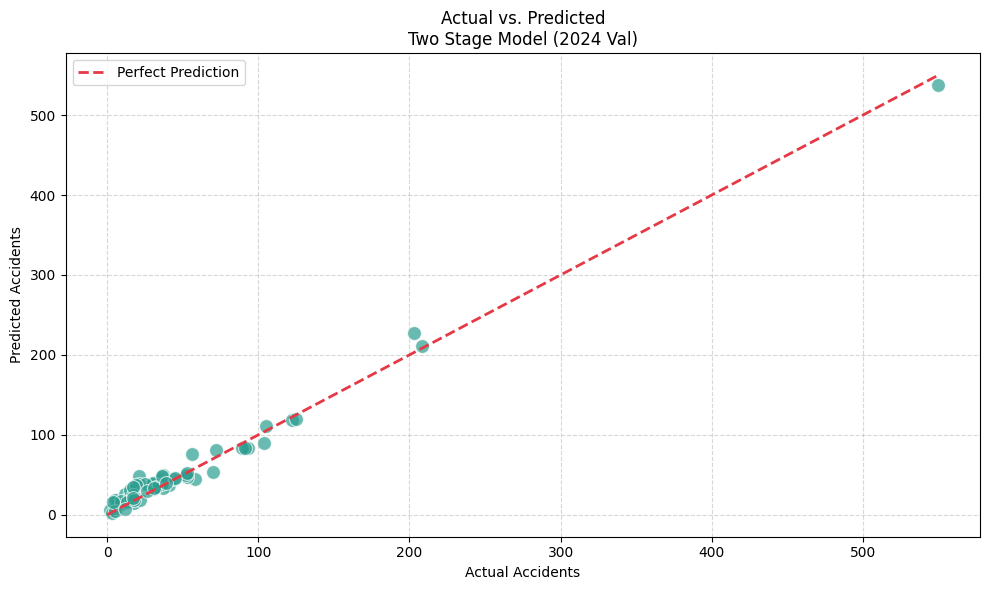

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(x=y_val, y=val_preds_1, alpha=0.7, color="#2A9D8F", s=100, ax=ax)

max_val = max(y_val.max(), val_preds_1.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)

ax.set_title("Actual vs. Predicted\nTwo Stage Model (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)


fig.tight_layout()

In [39]:
split_model_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_split_model", values=test_preds_1)
)

In [40]:
print("\nTop 10 High-Risk Municipalities — Two Stage Model (2025):")
print(split_model_results_2025.sort("pred_split_model", descending=True).head(10))


Top 10 High-Risk Municipalities — Two Stage Model (2025):
shape: (10, 3)
┌──────────┬──────┬──────────────────┐
│ gemeente ┆ year ┆ pred_split_model │
│ ---      ┆ ---  ┆ ---              │
│ str      ┆ i64  ┆ f64              │
╞══════════╪══════╪══════════════════╡
│ Gent     ┆ 2025 ┆ 617.934814       │
│ Brugge   ┆ 2025 ┆ 218.385935       │
│ Leuven   ┆ 2025 ┆ 202.699997       │
│ Kortrijk ┆ 2025 ┆ 138.4725         │
│ Mechelen ┆ 2025 ┆ 118.79592        │
│ Aalst    ┆ 2025 ┆ 115.425427       │
│ Genk     ┆ 2025 ┆ 97.636559        │
│ Hasselt  ┆ 2025 ┆ 95.877142        │
│ Lokeren  ┆ 2025 ┆ 91.036956        │
│ Oostende ┆ 2025 ┆ 86.045085        │
└──────────┴──────┴──────────────────┘


# Model 2
## XGBoost

In [41]:
# converting them to dmatrix makes the algorithm run faster
dtrain_xgb = xgb.DMatrix(X_train, label=y_train, weight=pop_weights)
dval_xgb = xgb.DMatrix(X_val, label=y_val)
dtest_xgb = xgb.DMatrix(X_test)

In [42]:
xgb_params = {
    "objective": "count:poisson",
    "eval_metric": "mae",
    "learning_rate": 0.02,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma": 0.1,
    "seed": 25,
}

In [43]:
model_xgb = xgb.train(
    xgb_params,
    dtrain_xgb,
    num_boost_round=1000,
    evals=[(dtrain_xgb, "train"), (dval_xgb, "val")],
    early_stopping_rounds=50,
    verbose_eval=100,
)

[0]	train-mae:127.13105	val-mae:100.03379
[100]	train-mae:51.46941	val-mae:40.14515
[200]	train-mae:19.41634	val-mae:18.33972
[300]	train-mae:7.55608	val-mae:9.98855
[400]	train-mae:3.19163	val-mae:7.69665
[500]	train-mae:1.65434	val-mae:6.90823
[600]	train-mae:1.14817	val-mae:6.65889
[700]	train-mae:0.97637	val-mae:6.58713
[800]	train-mae:0.94635	val-mae:6.57579
[827]	train-mae:0.94256	val-mae:6.57425


In [44]:
feat_imp_xgb = pd.Series(
    model_xgb.get_score(importance_type="gain"), name="gain"
).sort_values(ascending=False)

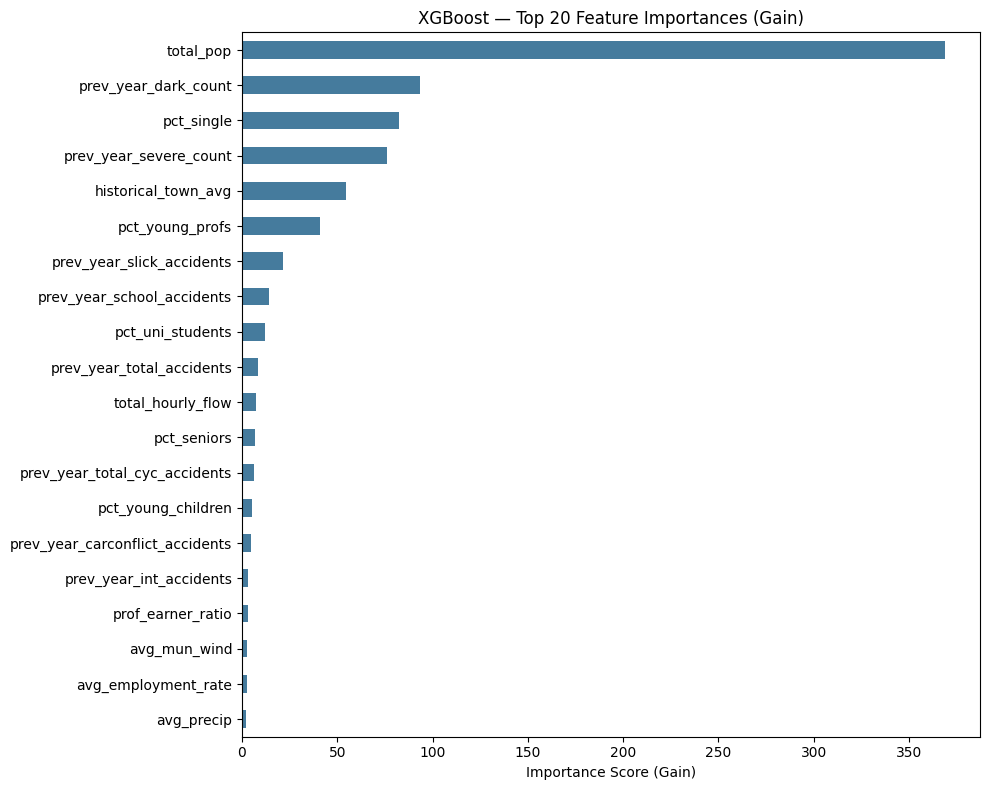

In [45]:
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp_xgb.head(20).plot(kind="barh", color="#457B9D", ax=ax)
ax.invert_yaxis()
ax.set_title("XGBoost — Top 20 Feature Importances (Gain)")
ax.set_xlabel("Importance Score (Gain)")
fig.tight_layout()

In [46]:
val_preds_xgb = model_xgb.predict(dval_xgb)

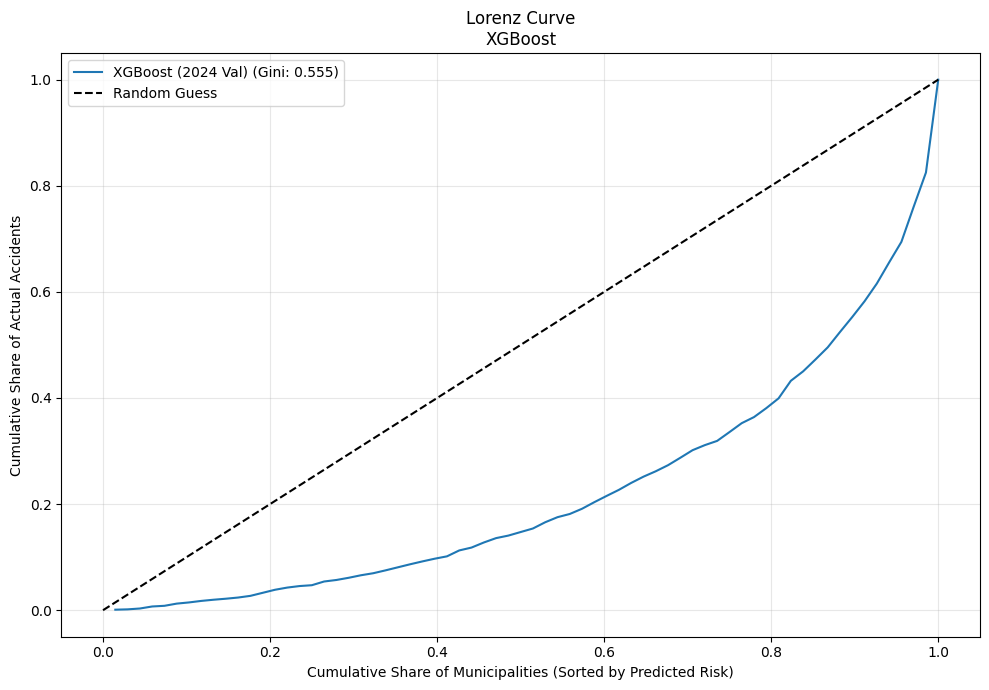

In [47]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_lorenz_curve(y_val, val_preds_xgb, "XGBoost (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")
ax.set_title("Lorenz Curve\nXGBoost")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

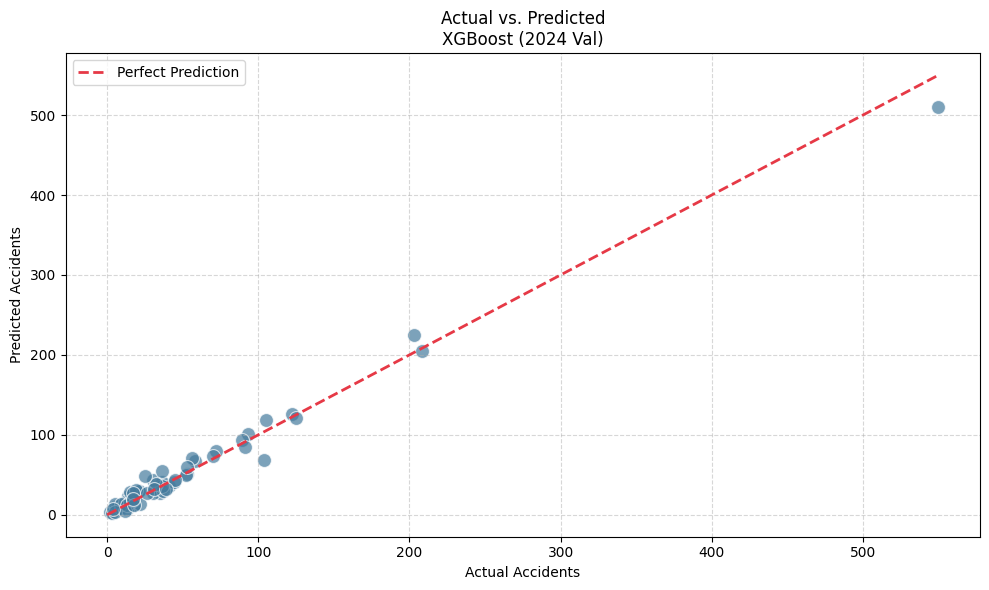

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=y_val, y=val_preds_xgb, alpha=0.7, color="#457B9D", s=100, ax=ax)
max_val = max(y_val.max(), val_preds_xgb.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)
ax.set_title("Actual vs. Predicted\nXGBoost (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()

In [49]:
test_preds_xgb = model_xgb.predict(dtest_xgb)
xgb_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_xgb", values=test_preds_xgb)
)

In [50]:
print("\nTop 10 High-Risk Municipalities — XGBoost (2025):")
print(xgb_results_2025.sort("pred_xgb", descending=True).head(10))


Top 10 High-Risk Municipalities — XGBoost (2025):
shape: (10, 3)
┌──────────┬──────┬────────────┐
│ gemeente ┆ year ┆ pred_xgb   │
│ ---      ┆ ---  ┆ ---        │
│ str      ┆ i64  ┆ f32        │
╞══════════╪══════╪════════════╡
│ Gent     ┆ 2025 ┆ 436.921021 │
│ Brugge   ┆ 2025 ┆ 223.022537 │
│ Leuven   ┆ 2025 ┆ 212.855362 │
│ Kortrijk ┆ 2025 ┆ 136.067078 │
│ Mechelen ┆ 2025 ┆ 133.056168 │
│ Aalst    ┆ 2025 ┆ 128.896683 │
│ Hasselt  ┆ 2025 ┆ 111.350479 │
│ Lokeren  ┆ 2025 ┆ 95.661537  │
│ Oostende ┆ 2025 ┆ 94.697334  │
│ Genk     ┆ 2025 ┆ 94.265465  │
└──────────┴──────┴────────────┘


# Model 3
## MERF

In [51]:
X_train_merf = train_df.select(features).to_pandas()
y_train_merf = train_df.select("smoothed_target").to_pandas().values.flatten()
clusters_train = train_df["gemeente"].to_pandas() # define the clusters
Z_train = np.ones((len(X_train_merf), 1)) # for the random effect

In [52]:
X_val_merf = val_df.select(features).to_pandas()
y_val_merf = val_df.select("smoothed_target").to_pandas().values.flatten()
clusters_val = val_df["gemeente"].to_pandas()
Z_val = np.ones((len(X_val_merf), 1))

In [53]:
X_test_merf = test_df.select(features).to_pandas()
clusters_test = test_df["gemeente"].to_pandas()
Z_test = np.ones((len(X_test_merf), 1))

In [54]:
model_merf = MERF(max_iterations=50)
model_merf.fit(X_train_merf, Z_train, clusters_train, y_train_merf)

INFO     [merf.py:307] Training GLL is 1014.7993621458995 at iteration 1.
INFO     [merf.py:307] Training GLL is 1080.7989137118288 at iteration 2.
INFO     [merf.py:307] Training GLL is 1109.754368330112 at iteration 3.
INFO     [merf.py:307] Training GLL is 1125.2890129203934 at iteration 4.
INFO     [merf.py:307] Training GLL is 1143.3968960436873 at iteration 5.
INFO     [merf.py:307] Training GLL is 1170.7186863423472 at iteration 6.
INFO     [merf.py:307] Training GLL is 1165.9573942026934 at iteration 7.
INFO     [merf.py:307] Training GLL is 1196.0974188676914 at iteration 8.
INFO     [merf.py:307] Training GLL is 1196.9209469455498 at iteration 9.
INFO     [merf.py:307] Training GLL is 1213.392096421822 at iteration 10.
INFO     [merf.py:307] Training GLL is 1226.9473012800354 at iteration 11.
INFO     [merf.py:307] Training GLL is 1220.0421061769985 at iteration 12.
INFO     [merf.py:307] Training GLL is 1241.9243467793317 at iteration 13.
INFO     [merf.py:307] Training GLL 

In [55]:
val_preds_merf = model_merf.predict(X_val_merf, Z_val, clusters_val)

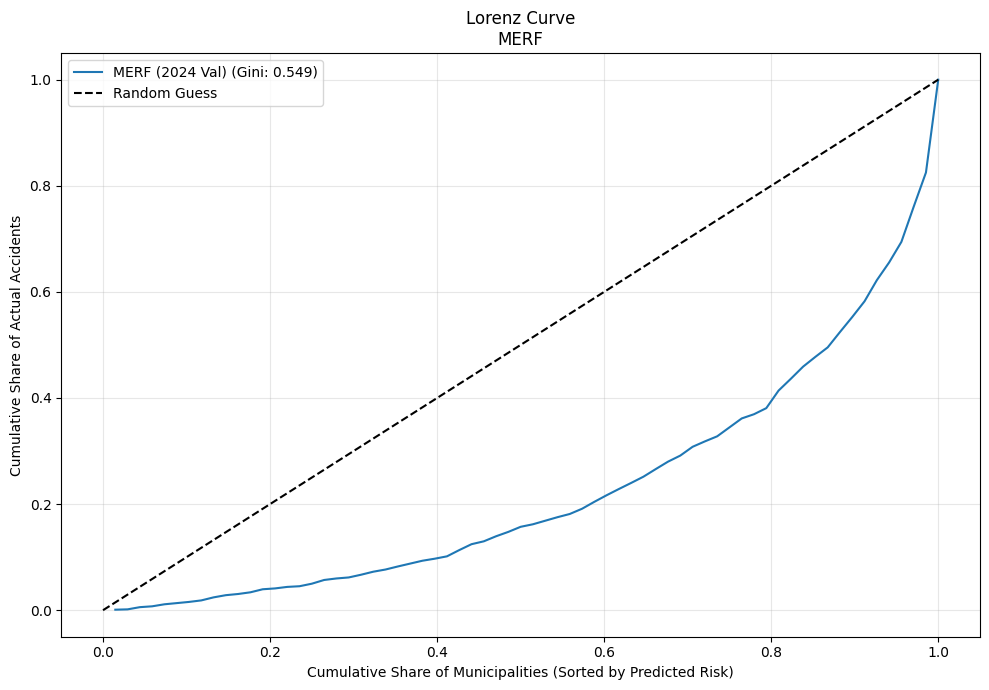

In [56]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_lorenz_curve(y_val_merf, val_preds_merf, "MERF (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")

ax.set_title("Lorenz Curve\nMERF")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

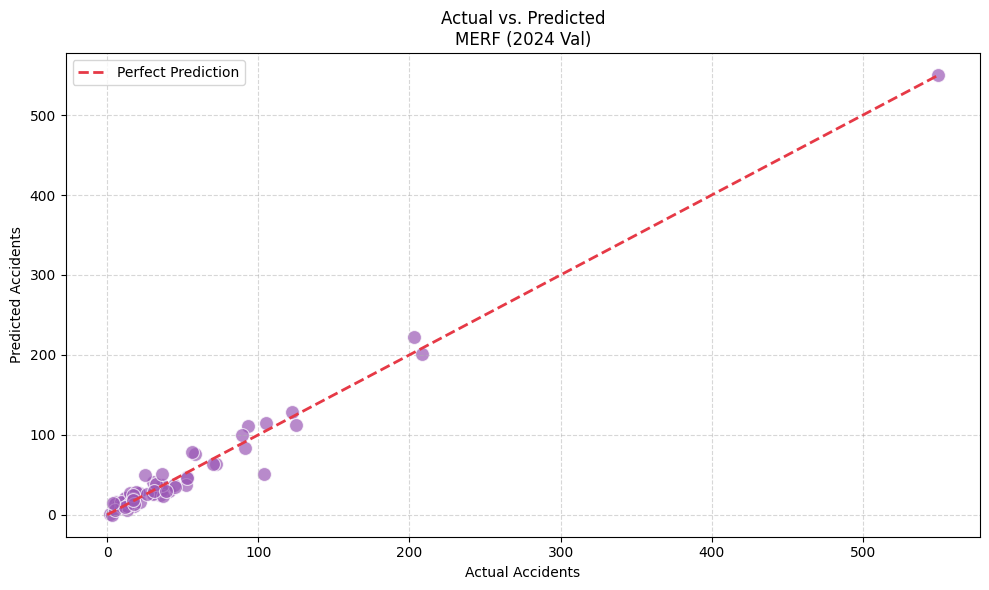

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x=y_val_merf, y=val_preds_merf, alpha=0.7, color="#9b59b6", s=100, ax=ax
)

max_val = max(y_val_merf.max(), val_preds_merf.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)

ax.set_title("Actual vs. Predicted\nMERF (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()

In [58]:
test_preds_merf = model_merf.predict(X_test_merf, Z_test, clusters_test)

merf_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_merf", values=test_preds_merf)
)

In [59]:
print("\nTop 10 High-Risk Municipalities — MERF (2025):")
print(merf_results_2025.sort("pred_merf", descending=True).head(10))


Top 10 High-Risk Municipalities — MERF (2025):
shape: (10, 3)
┌──────────┬──────┬────────────┐
│ gemeente ┆ year ┆ pred_merf  │
│ ---      ┆ ---  ┆ ---        │
│ str      ┆ i64  ┆ f64        │
╞══════════╪══════╪════════════╡
│ Gent     ┆ 2025 ┆ 556.842971 │
│ Brugge   ┆ 2025 ┆ 215.583505 │
│ Leuven   ┆ 2025 ┆ 202.536721 │
│ Kortrijk ┆ 2025 ┆ 134.287941 │
│ Mechelen ┆ 2025 ┆ 117.498337 │
│ Aalst    ┆ 2025 ┆ 116.315563 │
│ Hasselt  ┆ 2025 ┆ 102.455713 │
│ Genk     ┆ 2025 ┆ 96.799812  │
│ Lokeren  ┆ 2025 ┆ 95.732568  │
│ Oostende ┆ 2025 ┆ 87.796609  │
└──────────┴──────┴────────────┘


# Model Comparison

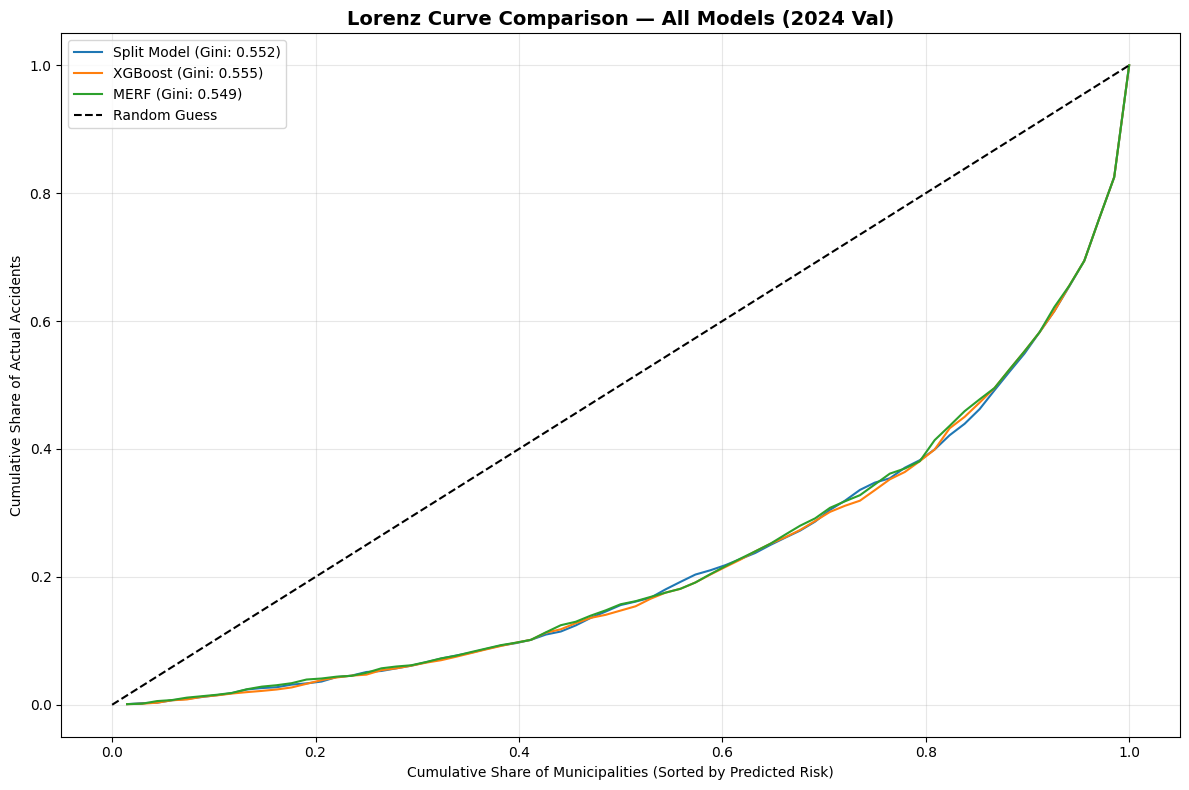

In [60]:
fig, ax = plt.subplots(figsize=(12, 8))

plot_lorenz_curve(y_val, val_preds_1, "Split Model", fig=fig, ax=ax)
plot_lorenz_curve(y_val, val_preds_xgb, "XGBoost", fig=fig, ax=ax)
plot_lorenz_curve(y_val_merf, val_preds_merf, "MERF", fig=fig, ax=ax)

ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")
ax.set_title(
    "Lorenz Curve Comparison — All Models (2024 Val)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

In [61]:
models_eval = {
    "Two Stage Model": (y_val, val_preds_1),
    "XGBoost": (y_val, val_preds_xgb),
    "MERF": (y_val_merf, val_preds_merf),
}

In [62]:
gini_summary = []
for name, (yt_, yp_) in models_eval.items():
    yt_ = np.array(yt_).flatten()
    yp_ = np.array(yp_).flatten()
    df_g = pd.DataFrame({"true": yt_, "pred": yp_}).sort_values("pred")
    cum_true = np.cumsum(df_g["true"]) / (df_g["true"].sum() + 1e-9)
    cum_pop = np.arange(1, len(cum_true) + 1) / len(cum_true)
    gini = 1 - 2 * np.trapezoid(cum_true, cum_pop)
    mae = np.mean(np.abs(yt_ - yp_))
    gini_summary.append(
        {"Model": name, "Gini Coefficient": round(gini, 4), "MAE": round(mae, 4)}
    )

In [63]:
df_summary = pd.DataFrame(gini_summary).sort_values("Gini Coefficient", ascending=False)

In [64]:
print("MODEL COMPARISON SUMMARY (2024 Validation)")
print("-" * 50)
print(df_summary.to_string(index=False))

MODEL COMPARISON SUMMARY (2024 Validation)
--------------------------------------------------
          Model  Gini Coefficient    MAE
        XGBoost            0.5547 6.5743
Two Stage Model            0.5524 7.6300
           MERF            0.5487 7.8981


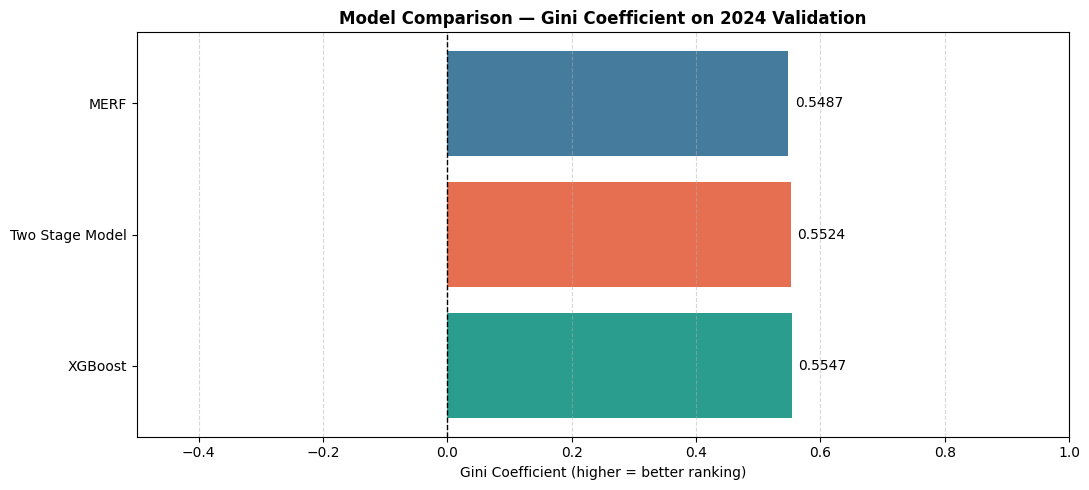

In [65]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = ["#2A9D8F", "#E76F51", "#457B9D", "#E63946", "#1D3557", "#9b59b6"]
bars = ax.barh(df_summary["Model"], df_summary["Gini Coefficient"], color=colors)
ax.axvline(x=0, color="black", linestyle="--", linewidth=1, label="Random Guess")

for bar, val in zip(bars, df_summary["Gini Coefficient"]):
    ax.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=10,
    )

ax.set_xlabel("Gini Coefficient (higher = better ranking)")
ax.set_title(
    "Model Comparison — Gini Coefficient on 2024 Validation", fontweight="bold"
)
ax.set_xlim(-0.5, 1.0)
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

fig.tight_layout()

In [66]:
df_mae = pd.DataFrame(gini_summary).sort_values("MAE")

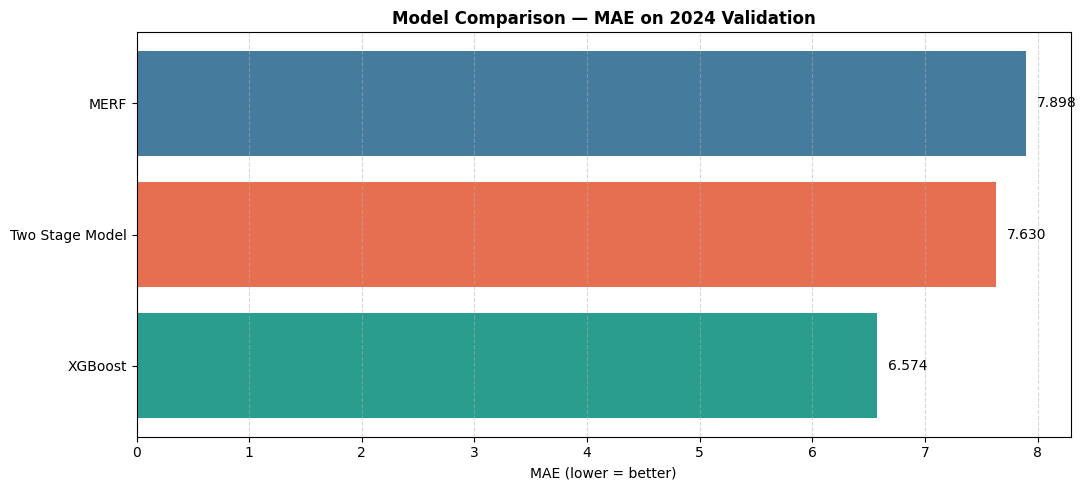

In [67]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#2A9D8F", "#E76F51", "#457B9D", "#E63946", "#1D3557", "#9b59b6"]
ax.barh(df_mae["Model"], df_mae["MAE"], color=colors)

for i, (_, row) in enumerate(df_mae.iterrows()):
    ax.text(row["MAE"] + 0.1, i, f'{row["MAE"]:.3f}', va="center", fontsize=10)

ax.set_xlabel("MAE (lower = better)")
ax.set_title("Model Comparison — MAE on 2024 Validation", fontweight="bold")
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

fig.tight_layout()

we're choosing **XGBoost** as our final model

In [68]:
final_results = (
    test_df.with_columns(
        pl.Series(
            name="predicted_num_accidents", values=test_preds_xgb.round().astype(int)
        )
    )
    .with_columns(
        [
            (pl.col("predicted_num_accidents") / pl.col("total_pop") * 1000).alias(
                "pred_per_1k_residents"
            ),
            pl.col("predicted_num_accidents").rank(descending=True).alias("risk_rank"),
        ]
    )
    .sort("risk_rank")
)

In [69]:
final_results[["gemeente", "predicted_num_accidents"]]

gemeente,predicted_num_accidents
str,i64
"""Gent""",437
"""Brugge""",223
"""Leuven""",213
"""Kortrijk""",136
"""Mechelen""",133
…,…
"""Wemmel""",5
"""Sint-Pieters-Leeuw""",4
"""Heers""",3


In [70]:
final_results = final_results.to_pandas()

In [71]:
type_cols = [
    "prev_year_slick_accidents",
    "prev_year_carconflict_accidents",
    "prev_year_int_accidents",
    "prev_year_school_accidents",
    "prev_year_dark_count",
]

In [72]:
means = final_results[type_cols].mean()
stds = final_results[type_cols].std().replace(0, 1)
z_scores = (final_results[type_cols] - means) / stds

In [73]:
striking_cols = z_scores.idxmax(axis=1)

In [74]:
name_map = {
    "prev_year_slick_accidents": "slick",
    "prev_year_carconflict_accidents": "car_conflict",
    "prev_year_int_accidents": "intersection",
    "prev_year_school_accidents": "school_accidents",
    "prev_year_dark_count": "dark"
}

In [75]:
final_results["most_frequent_type"] = striking_cols.map(name_map)

In [76]:
final_results["most_frequent_type"].value_counts()

most_frequent_type
dark                28
slick               13
intersection        11
car_conflict         8
school_accidents     8
Name: count, dtype: int64

In [77]:
final_results.to_csv("data/final_results.csv", index=False)

In [78]:
final_results.columns

Index(['gemeente', 'year', 'total_accidents', 'total_cycling_accidents',
       'car_conflict', 'severity', 'slick', 'light', 'intersection',
       'school_peak', 'local_accidents', 'total_hourly_flow', 'avg_temp',
       'avg_precip', 'avg_mun_wind', 'bad_weather_ratio',
       'relative_sensor_age', 'avg_income_per_capita', 'prof_earner_ratio',
       'avg_employment_rate', 'inbound_push_ratio', 'total_pop',
       'pct_young_children', 'pct_school_kids', 'pct_uni_students',
       'pct_young_profs', 'pct_senior_profs', 'pct_seniors', 'pct_male',
       'pct_female', 'pct_belgian', 'pct_foreign', 'pct_single', 'pct_married',
       'pct_widowed', 'pct_divorced', 'accident_rate_per_flow',
       'accident_rate_per_capita', 'severity_index', 'prev_year_severe_count',
       'prev_year_dark_count', 'prev_year_local_accidents',
       'prev_year_school_accidents', 'prev_year_slick_accidents',
       'prev_year_carconflict_accidents', 'prev_year_int_accidents',
       'prev_year_total_ac

In [79]:
final_results.iloc[0]

gemeente                                   Gent
year                                       2025
total_accidents                               0
total_cycling_accidents                       0
car_conflict                                  0
severity                                      0
slick                                         0
light                                         0
intersection                                  0
school_peak                                   0
local_accidents                               0
total_hourly_flow                   4454.482422
avg_temp                              12.230687
avg_precip                             0.050635
avg_mun_wind                          11.941783
bad_weather_ratio                        0.0869
relative_sensor_age                         3.0
avg_income_per_capita              25795.208984
prof_earner_ratio                      0.626307
avg_employment_rate                    0.742867
inbound_push_ratio                     0